## Cointegration with Financial Data

#### A Look at FAANG stocks

The five stocks that make up the "FAANG" acronym - Meta (FB), Amazon (AMZN), Apple (AAPL), Netflix (NFLX), and Alphabet (GOOG).

In [2]:
import pandas as pd
import yfinance as yf
from statsmodels.tsa.vector_ar.vecm import coint_johansen

In [3]:
tickers = ['META', 'AMZN', 'AAPL', 'NFLX', 'GOOG']
df = yf.download(tickers, period='max')

/tmp/ipykernel_19491/677449210.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, period='max')
[*********************100%***********************]  5 of 5 completed


In [4]:
df = df['Close'].dropna()

In [5]:
df

Ticker,AAPL,AMZN,GOOG,META,NFLX
Date,,,,,
2012-05-18,15.891782,10.692500,14.832178,37.932323,0.999429
2012-05-21,16.817633,10.905500,15.170867,33.765034,1.024857
2012-05-22,16.688494,10.766500,14.842059,30.758623,0.967286
2012-05-23,17.095694,10.864000,15.055994,31.750837,1.027286
2012-05-24,16.938686,10.762000,14.912713,32.772816,1.003857
...,...,...,...,...,...
2026-05-04,276.829987,272.049988,379.640015,610.409973,91.019997
2026-05-05,284.179993,273.549988,384.269989,604.960022,87.889999
2026-05-06,287.510010,274.989990,395.140015,612.880005,88.269997


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

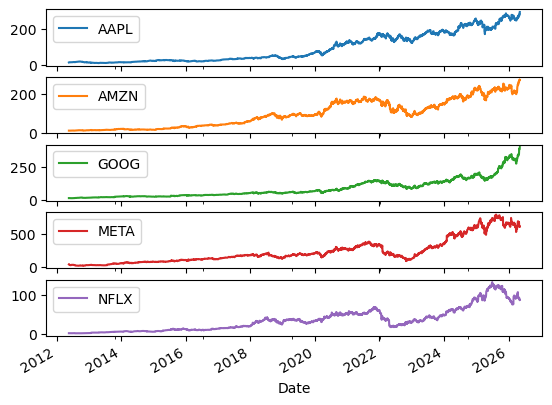

In [6]:
df.plot(subplots=True)

In [9]:
def coint_test(df, alpha=0.05):
    """
    Cointegration Test and Report 
    """
    out = coint_johansen(df, -1, 5)
    d = {'0.90':0, '0.95': 1, '0.99': 2}
    traces = out.lr1
    cvts = out.cvt[:, d[str(1 - alpha)]]

    def adjust(val, length=6):
        return str(val).ljust(length)

    print("Name\t||\t Test Stat>C(95%)\t=>Signif\t\n", '--'*20)
    for col, trace, cvt in zip(df.columns, traces, cvts):
        print(adjust(col), "|| ", adjust(round(trace, 2), 9), ">", adjust(cvt, 8), " => ", trace > cvt)

In [10]:
coint_test(df)

Name	||	 Test Stat>C(95%)	=>Signif	
 ----------------------------------------
AAPL   ||  99.28     > 60.0627   =>  True
AMZN   ||  42.89     > 40.1749   =>  True
GOOG   ||  23.46     > 24.2761   =>  False
META   ||  6.61      > 12.3212   =>  False
NFLX   ||  0.35      > 4.1296    =>  False
